In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('Confronto prima_inizio e durante.xlsx') #importazione del file per i dati in excel

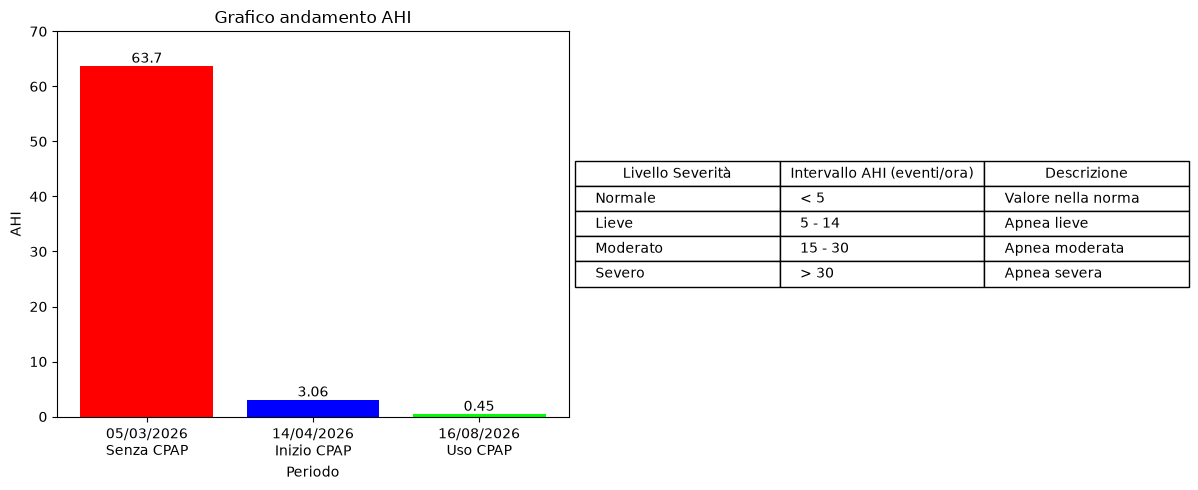

In [4]:
dati_ahi = { #dati legenda
    "Livello Severità": ["Normale", "Lieve", "Moderato", "Severo"],
    "Intervallo AHI (eventi/ora)": ["< 5", "5 - 14", "15 - 30", "> 30"],
    "Descrizione": [
        "Valore nella norma",
        "Apnea lieve",
        "Apnea moderata",
        "Apnea severa",
    ],
}
df_legenda = pd.DataFrame(dati_ahi)

etichette = ['05/03/2026\nSenza CPAP', '14/04/2026\nInizio CPAP', '16/08/2026\nUso CPAP'] #commento sotto barre staccato
colori = ['red', 'blue', '#00FF00'] #colori    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) #cerazione figure a destra e sinistra

bars = ax1.bar(etichette, df['AHI'], color=colori) #creazione tabella con barre
ax1.bar_label(bars) #ogni barra ha il suo valore in alto
ax1.set_xlabel('Periodo') #definizione nomi degli assi
ax1.set_ylabel('AHI')
ax1.set_title('Grafico andamento AHI') #titolo
ax1.set_ylim(0, 70) #ingrandimento spazio asse y (alto) 

ax2.axis('off') #nasconde gli assi
tabella = ax2.table(
    cellText=df_legenda.values,
    colLabels=df_legenda.columns,
    cellLoc='left',
    loc='center'
)
tabella.auto_set_font_size(False)
tabella.set_fontsize(10)
tabella.scale(1.2, 1.5)

plt.tight_layout()
plt.show() #crea il grafico con istruzioni sopra

In [15]:
import pandas as pd

In [16]:
import matplotlib.pyplot as plt

In [17]:
import matplotlib.dates as mdates

In [18]:
df = pd.read_excel('AHI giornaliero ok orario.xlsx')

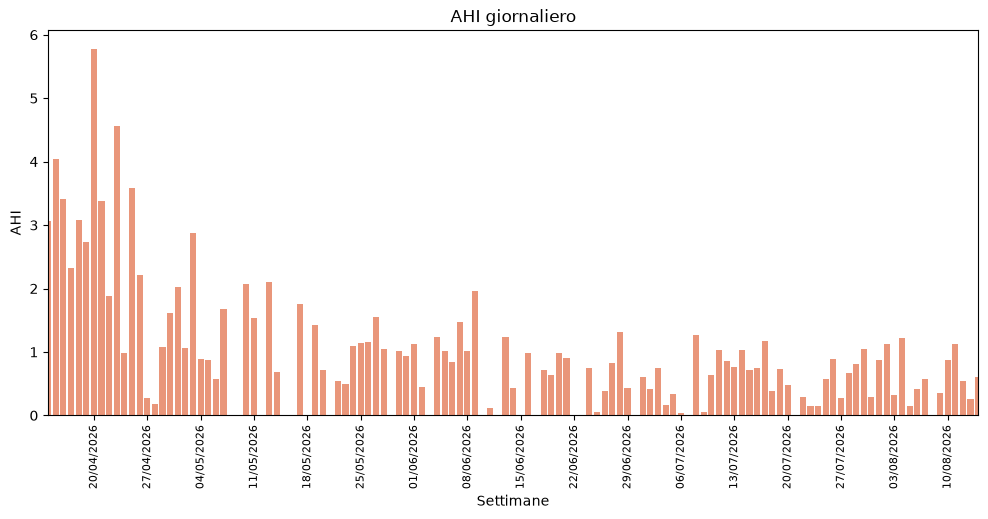

In [19]:
df['Period'] = pd.to_datetime(df['Period'], format='%d/%m/%Y') #converte colonna Period in vera data
fig, ax = plt.subplots(figsize=(12, 5)) #crea figura
ax.bar(df['Period'], df['AHI'], color='darksalmon', width=0.8) #dati giornalieri
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO)) #imposta tick su asse x
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y')) #formatta data visibile asse x

plt.xticks(rotation=90, fontsize=8) #ruota date e rimpicciolisce testo asse x
plt.xlim(df['Period'].min(), df['Period'].max())  

plt.title('AHI giornaliero')
plt.xlabel('Settimane')
plt.ylabel('AHI')

plt.show()

In [26]:
import pandas as pd

In [27]:
import matplotlib.pyplot as plt

In [28]:
import numpy as np

In [29]:
import matplotlib.dates as mdates #installa gestione calendario

In [30]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [31]:
df = pd.read_excel('EPAP definitivo.xlsx')

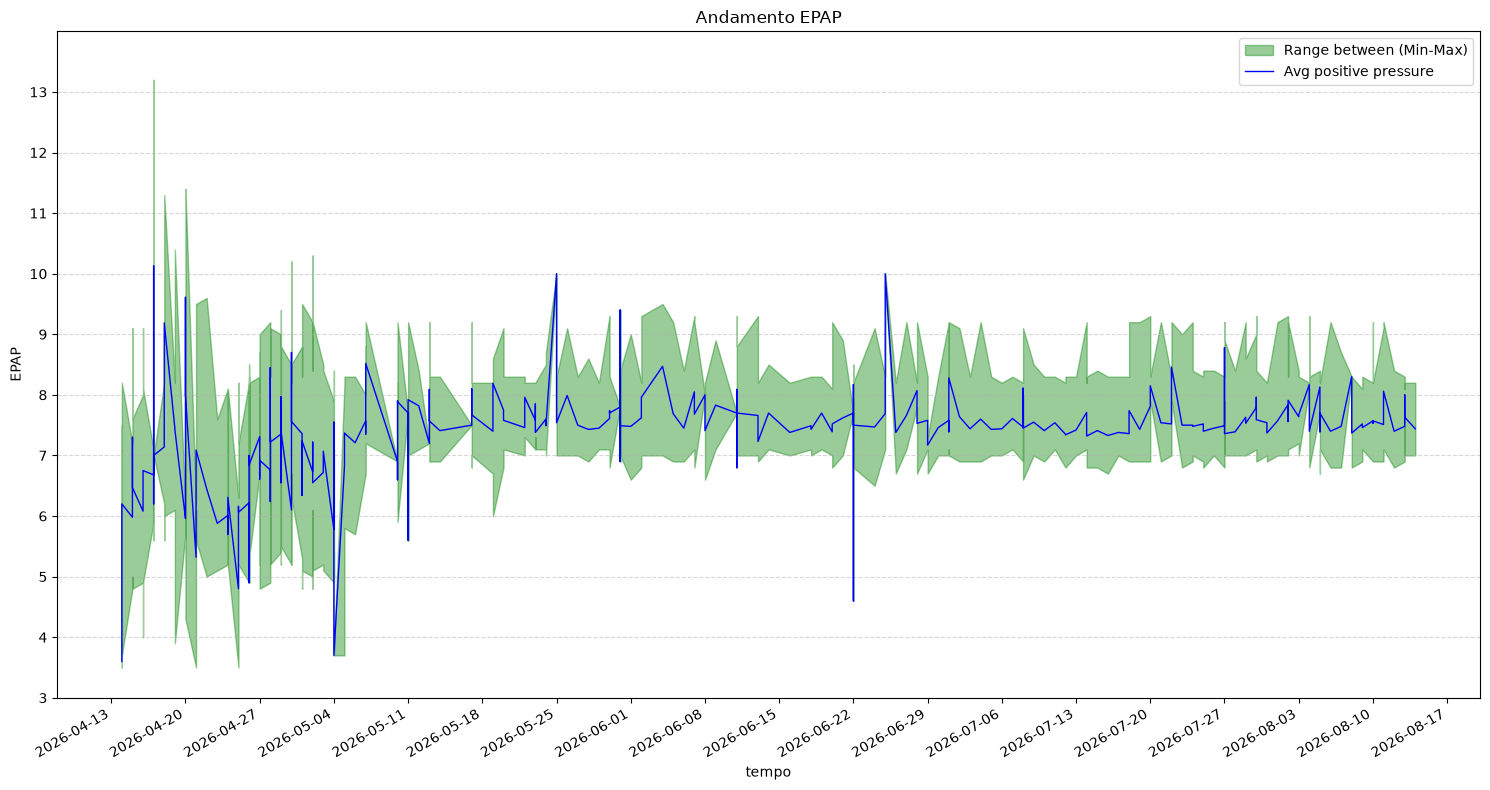

In [32]:
df_clean = df.iloc[1:].copy() #rimuove prima riga intestazione colonne
df_clean['tempo'] = pd.to_datetime(df_clean['Column4'], errors='coerce')
df_clean['Min'] = pd.to_numeric(df_clean['Column11'], errors='coerce')
df_clean['Avg'] = pd.to_numeric(df_clean['Column12'], errors='coerce')
df_clean['Max'] = pd.to_numeric(df_clean['Column17'], errors='coerce')
df_clean = df_clean.dropna(subset=['tempo', 'Min', 'Avg', 'Max'])

plt.figure(figsize=(15, 8))
plt.fill_between(df_clean['tempo'], df_clean['Min'], df_clean['Max'], color='green', alpha=0.4, label='Range between (Min-Max)') #alpha= trasparenza dei grafici
plt.plot(df_clean['tempo'], df_clean['Avg'], color='blue', linewidth=1, label='Avg positive pressure')

plt.gca().xaxis.set_major_locator(
    mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) #cambiamento tacche asse x con settimanale, ogni lunedì

plt.ylim(3, 14) #limiti esatti dati asse y
plt.yticks(np.arange(3, 14, 1)) #riferimenti intermedi asse y
plt.grid(True, axis='y', linestyle='--', alpha=0.5) #griglia orizzontale valori

plt.xlabel('tempo')
plt.ylabel('EPAP')
plt.title('Andamento EPAP')
plt.legend() #per distinguere colori
plt.gcf().autofmt_xdate() #formatta l'asse delle date
plt.tight_layout()

plt.show()  

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
df = pd.read_excel('AHI giornaliero ok orario.xlsx')

In [5]:
matrice_corr = df[['AHI', 'OA', 'H', 'CA', 'Colonna1']].corr(method='pearson') #calcola pearson escludendo colonne vuote/non numeriche
print(matrice_corr)

               AHI        OA         H        CA  Colonna1
AHI       1.000000  0.641080  0.654137  0.559987 -0.069798
OA        0.641080  1.000000  0.318182  0.534308  0.139937
H         0.654137  0.318182  1.000000  0.340512  0.225163
CA        0.559987  0.534308  0.340512  1.000000  0.093553
Colonna1 -0.069798  0.139937  0.225163  0.093553  1.000000


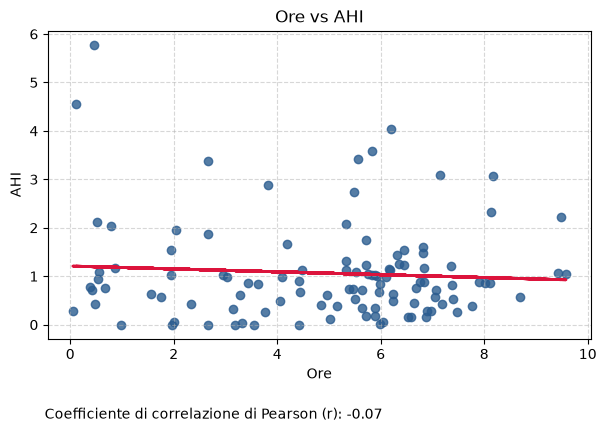

In [6]:
x1 = df['Colonna1'] #grafico 1: Hours vs AHI
y1 = df['AHI']
r = x1.corr(y1) #calcolo correlazione

plt.figure(figsize=(7, 4))
plt.scatter(x1, y1, color='#2b5c8f', alpha=0.8)

m1, b1 =np.polyfit(x1, y1, 1) #calcolo retta regressione
plt.plot(x1, m1*x1 + b1, color='crimson', linewidth=2) 
plt.title('Ore vs AHI')
plt.xlabel('Ore')
plt.ylabel('AHI')
plt.grid(True, linestyle='--', alpha=0.5)

testo_didascalia = f'Coefficiente di correlazione di Pearson (r): {r:.2f}'
plt.figtext(0.12, -0.09, testo_didascalia, fontsize=10, ha='left') #didascalia sotto il grafico

plt.show()

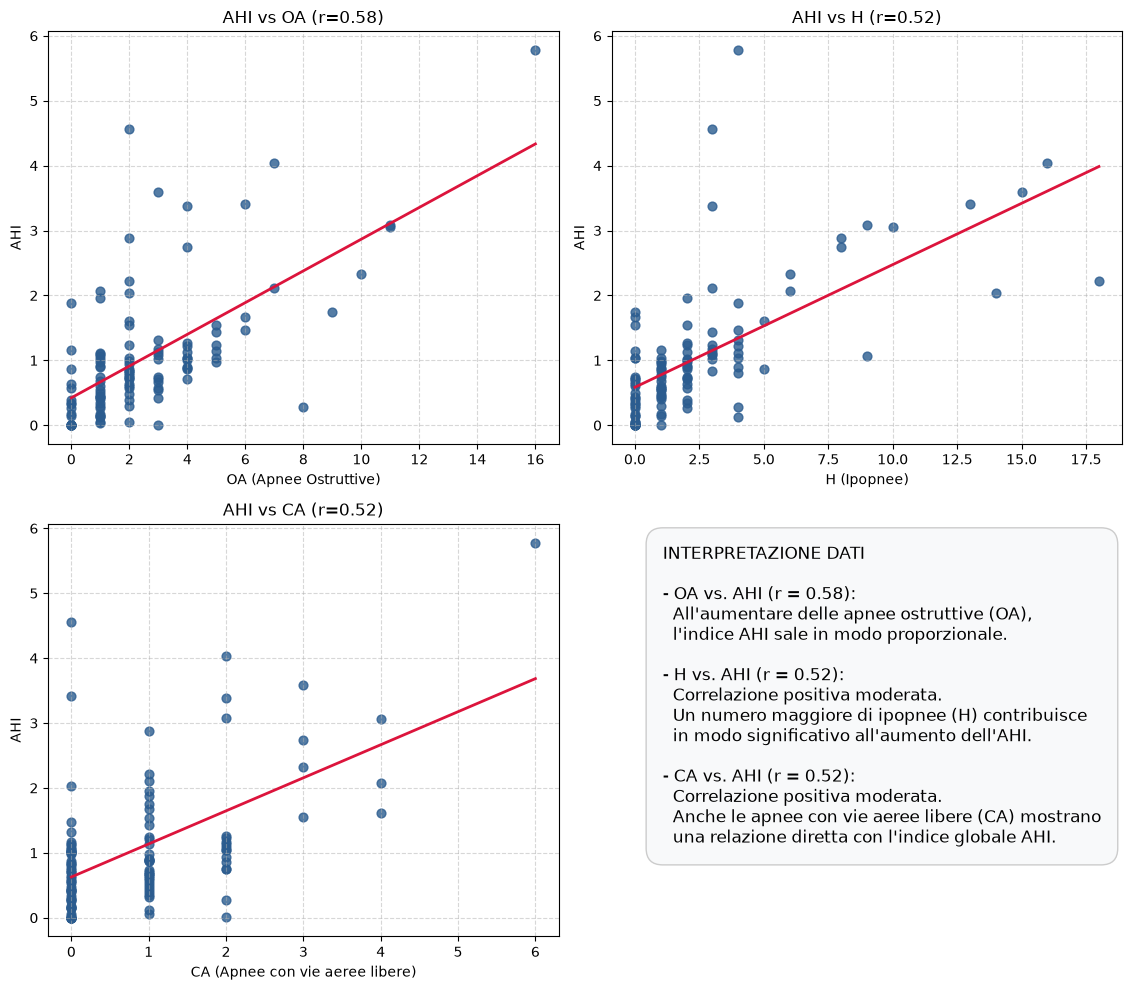

In [7]:
colonne =['AHI', 'OA', 'H', 'CA', 'Colonna1']
df_corr = df[colonne].corr(method='pearson') #calcolo matrice
matrice_vals = df_corr.values

fig, axes = plt.subplots(2, 2, figsize=(12, 10)) #creazione layout 2x2

x1, y1 = df['OA'], df['AHI'] #grafico OA vs AHI
axes[0, 0].scatter(x1, y1, color='#2b5c8f', alpha=0.8, s=40)
m1, b1 = np.polyfit(x1, y1, 1)
x_seq1 = np.linspace(x1.min(), x1.max(), 100)
axes[0, 0].plot(x_seq1, m1 * x_seq1 + b1, color='crimson', linewidth=2)
axes[0, 0].set_title('AHI vs OA (r=0.58)', fontsize=12)
axes[0, 0].set_xlabel('OA (Apnee Ostruttive)')
axes[0, 0].set_ylabel('AHI')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

x2, y2 = df['H'], df['AHI'] #grafico H vs AHI
axes[0, 1].scatter(x2, y2, color='#2b5c8f', alpha=0.8, s=40)
m2, b2 = np.polyfit(x2, y2, 1)
x_seq2 = np.linspace(x2.min(), x2.max(), 100)
axes[0, 1].plot(x_seq2, m2 * x_seq2 + b2, color='crimson', linewidth=2)
axes[0, 1].set_title('AHI vs H (r=0.52)', fontsize=12)
axes[0, 1].set_xlabel('H (Ipopnee)')
axes[0, 1].set_ylabel('AHI')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

x3, y3 = df['CA'], df['AHI'] #grafico CA vs AHI
axes[1, 0].scatter(x3, y3, color='#2b5c8f', alpha=0.8, s=40)
m3, b3 = np.polyfit(x3, y3, 1)
x_seq3 = np.linspace(x3.min(), x3.max(), 100)
axes[1, 0].plot(x_seq3, m3 * x_seq3 + b3, color='crimson', linewidth=2)
axes[1, 0].set_title('AHI vs CA (r=0.52)', fontsize=12)
axes[1, 0].set_xlabel('CA (Apnee con vie aeree libere)')
axes[1, 0].set_ylabel('AHI')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)


axes[1, 1].axis('off') #interpretazione
testo_interpretazione = (
    "INTERPRETAZIONE DATI\n\n"
    "- OA vs. AHI (r = 0.58):\n"
    "  All'aumentare delle apnee ostruttive (OA),\n"
    "  l'indice AHI sale in modo proporzionale.\n\n"
    "- H vs. AHI (r = 0.52):\n"
    "  Correlazione positiva moderata.\n"
    "  Un numero maggiore di ipopnee (H) contribuisce\n"
    "  in modo significativo all'aumento dell'AHI.\n\n"
    "- CA vs. AHI (r = 0.52):\n"
    "  Correlazione positiva moderata.\n"
    "  Anche le apnee con vie aeree libere (CA) mostrano\n"
    "  una relazione diretta con l'indice globale AHI."
)
axes[1, 1].text(0.1, 0.95, testo_interpretazione, transform=axes[1, 1].transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#cccccc'))

axes[1, 1].axis('off') #togliere grefico in più che sarebbe vuoto

plt.tight_layout()
plt.show()

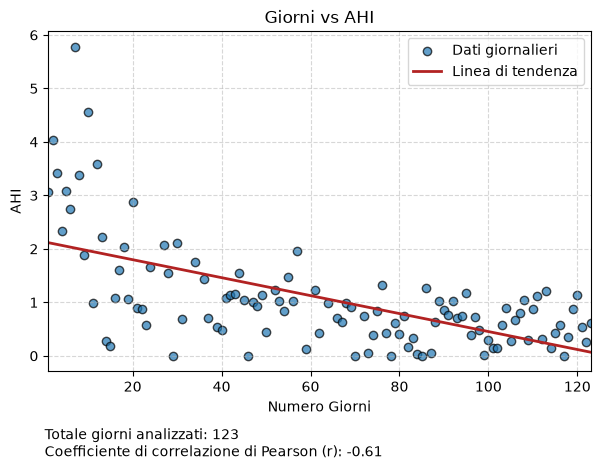

In [8]:
date_convertite = pd.to_datetime(df['Period'], dayfirst=True) #conversione date in numero progressivo

x = (date_convertite - date_convertite.min()).dt.days + 1 #calcolo dei giorni trascorsi dalla prima data presente
y = df['AHI']

r = x.corr(y) #calcolo correlazione

m, q = np.polyfit(x, y, 1) #calcolo retta regressione
x_line = np.array([x.min(), x.max()]) #prende dal primo all'ultimo giorno
y_line = m * x_line + q

plt.figure(figsize=(7, 5)) #creazione grafico
plt.scatter(x, y, color='tab:blue', alpha=0.7, edgecolors='k', label='Dati giornalieri') #scatter plot dei punti
plt.plot(x_line, y_line, color='firebrick', linewidth=2, label='Linea di tendenza') #retta di regressione

plt.xlim(1, x.max()) #blocco asse x dal primo all'ultimo giorno analizzato

plt.title('Giorni vs AHI', fontsize=12)
plt.xlabel('Numero Giorni', fontsize=10)
plt.ylabel('AHI', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplots_adjust(bottom=0.20) #aggiusta margine sotto per didascalia
testo_didascalia = f'Totale giorni analizzati: {x.max()}\nCoefficiente di correlazione di Pearson (r): {r:.2f}'
plt.figtext(0.12, 0.03, testo_didascalia, fontsize=10, ha='left')

plt.show()